In [1]:
from datetime import datetime
import git
from IPython.display import display, Markdown
import re

def ipynb_stamp():
    """Display the current git commit hash and timestamp in a Jupyter notebook.
    """
    def remote_https_url(repo):
        try:
            url = next(repo.remote("origin").urls)
        except (ValueError, StopIteration):
            return None

        # Handle SSH form: git@github.com:me/repo(.git)
        m = re.match(r"git@([^:]+):(.+?)(?:\.git)?$", url)
        if m:
            return f"https://{m.group(1)}/{m.group(2)}"

        # Handle https form: strip .git if present
        if url.startswith("http"):
            return url.removesuffix(".git")

        # If not the above formats, return None
        return None

    def offset_str(dt):
        if dt.tzinfo is not None:
            offset_td = dt.tzinfo.utcoffset(dt)
            if offset_td is None:
                return "+0000"
            offset_seconds = int(offset_td.total_seconds())
            sign = '+' if offset_seconds >= 0 else '-'
            hours, remainder = divmod(abs(offset_seconds), 3600)
            minutes, _ = divmod(remainder, 60)
            return f"{sign}{hours:02}{minutes:02}"
        return "+0000"

    def time_str(timestamp):
        if timestamp.tzinfo is None:
            # If the commit time is naive, assume local timezone
            timestamp = timestamp.astimezone()
        return timestamp.strftime('%Y-%m-%d %H:%M:%S') + " " + offset_str(timestamp)
    
    try:
        repo = git.Repo('.', search_parent_directories=True)
    except (git.InvalidGitRepositoryError, git.NoSuchPathError):
        print("Git not initialized in this directory.")
        return

    # Branch name (handle detached HEAD explicitly)
    if getattr(repo.head, "is_detached", False):
        branch_name = "detached HEAD"
    else:
        branch_name = repo.active_branch.name

    # Get commit hash (truncate to 12 chars) and dirty flag
    short_hash = repo.head.commit.hexsha[:12]
    dirty_flag = '*' if repo.is_dirty(untracked_files=True) else ''
    print('Git commit hash: ' + short_hash + dirty_flag
          + ' (' + branch_name + ')')

    # Get commit timestamp
    timestamp = repo.head.commit.committed_datetime#.astimezone()
    print('Git commit Time: ' + time_str(timestamp))

    # Get notebook render timestamp
    render_time = datetime.now().replace(microsecond=0).astimezone()
    print('Notebook render Time: ' + time_str(render_time))

    # Note: link will only work if commit has been pushed to the remote repository.
    remote_url = remote_https_url(repo)
    if remote_url:
        display(Markdown(f"<{remote_url}/commit/{short_hash}>"))
    else:
        print("No URL found for remote 'origin'.")

ipynb_stamp()

! git status -bs --ahead-behind


Git commit hash: fed702d832d3* (v0.2)
Git commit Time: 2025-08-09 09:01:04 +0100
Notebook render Time: 2025-08-09 09:01:30 +0100


<https://github.com/yinchi/cuh-resp-model/commit/fed702d832d3>

## v0.2...origin/v0.2
?? simulation_module.ipynb


In [2]:
import json
import pandas as pd
from matplotlib import pyplot as plt

## Load configuration

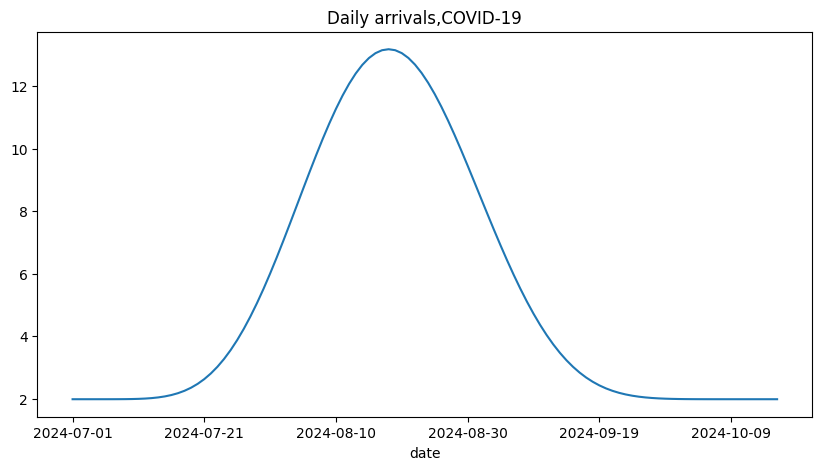

,0,1,2
lower,0,16,65
upper,16.0,65.0,NaN
query,Age >= 0 and Age < 16,Age >= 16 and Age < 65,Age >= 65
ratio,0.040506,0.317722,0.641772
dist_type,gamma,chi2,gamma
dist_params,"{'a': 0.6331661087258936, 'loc': 0.60378074074...","{'df': 1.2466507110020126, 'loc': 0.3656059259...","{'a': 1.069561598886756, 'loc': 0.195737660528..."


In [3]:
with open('simulation_config/config.json', 'r', encoding='utf-8') as fp:
    config = json.load(fp)

disease_name = config['step1']['disease_name']
scenario_df = pd.DataFrame.from_dict(config['step2']['scenario_df'], orient='tight')
age_df = pd.DataFrame.from_dict(config['step3']['age_groups'], orient='columns')

scenario_df.plot(x='date', y='y', kind='line',
                 title=f'Daily arrivals,{disease_name}',
                 figsize=(10, 5), legend=False)
plt.show()

display(age_df.T)

## Simulate

In [4]:
from cuh_resp_model.sim import sim, get_quantiles, gen_plotly

In [5]:
sim_results = sim(scenario_df, age_df)

## Plot quantiles

In [6]:
q = get_quantiles(sim_results.overall_beds_list)
fig = gen_plotly(q, title=f'Overall bed occupancy, {disease_name}')
fig.show()

In [7]:
age_groups = age_df['query'].to_list()
age_groups

['Age >= 0 and Age < 16', 'Age >= 16 and Age < 65', 'Age >= 65']

In [8]:
for g in age_groups:
    q = get_quantiles([l[g] for l in sim_results.beds_by_age_list])
    fig = gen_plotly(q, title=f'Bed occupancy by age group: {g}')
    fig.show()

In [9]:
selected_age_groups = age_groups[1:]  # Example: select the first age group for demonstration

def group_sum(dfs, selected_age_groups):
    """
    Combine the bed occupancy data for selected age groups into a single series.
    """
    return pd.concat(
        (dfs[g] for g in selected_age_groups),
        axis=1, join='outer'
    ).ffill().sum(axis=1)

q = get_quantiles(
    list(group_sum(dfs, selected_age_groups) for dfs in sim_results.beds_by_age_list)
)
fig = gen_plotly(q, title='Bed occupancy for selected age groups')
fig.show()

## Serialization and deserialization

In [10]:
from cuh_resp_model.sim import sim_results_from_dict, sim_results_to_dict

In [11]:
sim_results_dict = sim_results_to_dict(sim_results)

Example values:

In [13]:
sim_results_dict['overall_beds_list'][0]['2024-08-01T00:00:00']

46.0

In [14]:
sim_results_dict['beds_by_age_list'][0][age_groups[-1]]['2024-08-01T00:00:00']

34.0

In [15]:
len(sim_results_dict['overall_beds_list'])

30

In [16]:
len(sim_results_dict['beds_by_age_list'])

30

Check the deserialization

In [17]:
deserialized = sim_results_from_dict(sim_results_dict)

In [18]:
for g in age_groups:
    q = get_quantiles([l[g] for l in deserialized.beds_by_age_list])
    fig = gen_plotly(q, title=f'Bed occupancy by age group: {g}')
    fig.show()

In [19]:
q = get_quantiles(
    list(group_sum(dfs, selected_age_groups) for dfs in sim_results.beds_by_age_list)
)
fig = gen_plotly(q, title='Bed occupancy for selected age groups')
fig.show()